## **Distribution and Tail Risk**

**Goal**  
 Dive into return distribution and analyze tail risks by calculating VaR, CVaR, and maximum drawdown.
 
**Stocks**  
AAPL, MSFT, NVDA, META, GOOGL, SPY

**Key questions**  
- What does the daily return distribution look like for each stock? Are they normally distributed?
- Compared to a normal distribution, are the tails fatter or thinner?
- At a given confidence level, how much could you lose in a single day in a worst-case scenario? And if you do land in that tail, how bad is the average loss?
- Historically, what was the worst peak-to-trough decline for each stock? How deep did the account fall from its high before recovering?

In [1]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import yfinance as yf

# Load data, the same as Notebook 1
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'META', 'GOOGL', 'SPY']
START   = '2020-01-01'
END     = '2025-12-31'

prices = pd.read_csv('data/prices_clean.csv', index_col=0, parse_dates=True)
returns = prices.pct_change().dropna()

print(f"Shape: {returns.shape}")
print(f"Date range: {returns.index[0].date()} → {returns.index[-1].date()}")

Shape: (1506, 6)
Date range: 2020-01-03 → 2025-12-30


### **Part 1 - Distribution Analysis**
- Return Distribution Histogram
- Skewness and Kurtosis
- Quantile-Quantile Plots
- Shapiro-Wilk Normality Test

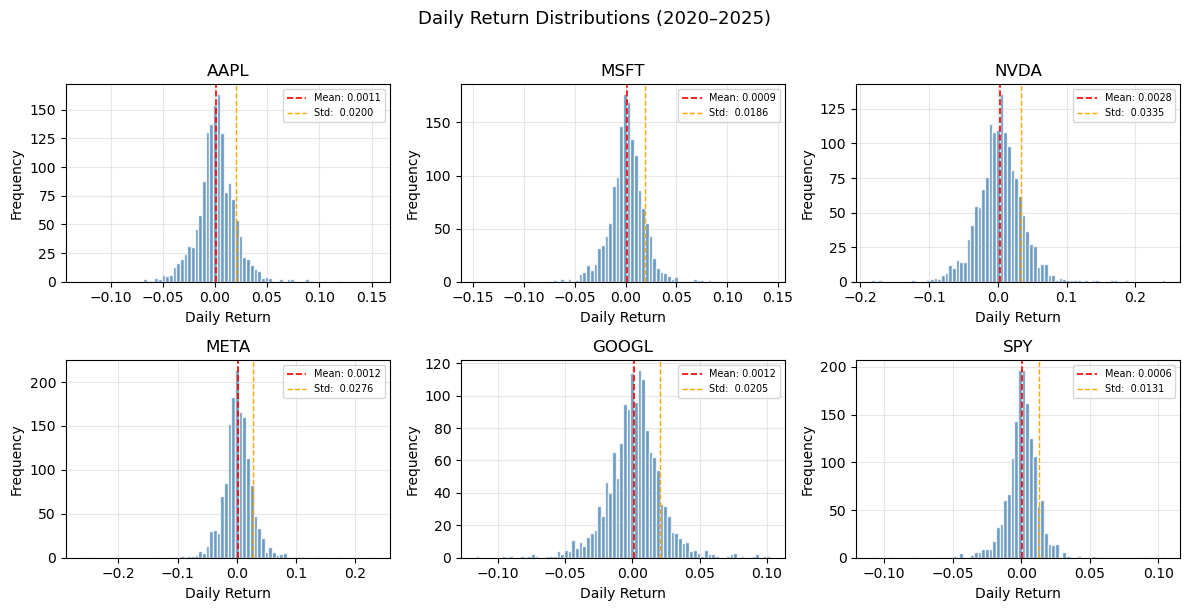

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    data = returns[ticker].dropna()
    
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.4f}')
    ax.axvline(data.std(),  color='orange', linestyle='--', linewidth=1.0, label=f'Std:  {data.std():.4f}')
    
    ax.set_title(ticker)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Daily Return Distributions (2020–2025)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('charts/return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
desc = returns.describe().T
desc['skewness'] = returns.skew()
desc['kurtosis'] = returns.kurtosis()

print(desc[['mean', 'std', 'skewness', 'kurtosis']].round(4))

          mean     std  skewness  kurtosis
Ticker                                    
AAPL    0.0011  0.0200    0.2840    6.7887
GOOGL   0.0012  0.0205    0.0034    3.5959
META    0.0012  0.0276   -0.1899   17.4938
MSFT    0.0009  0.0186    0.1055    7.5307
NVDA    0.0028  0.0335    0.3508    4.5129
SPY     0.0006  0.0131   -0.2653   13.0442


### Interpreting skewness and kurtosis:
Skewness < 0 → left tail is longer (more extreme negative days)  
Skewness > 0 → right tail is longer (more extreme positive days)  
Kurtosis < 0 → more normal distribution predicts than extreme events  
Kurtosis > 0 → more extreme events than normal distribution predicts  
Normal distribution has skewness = 0, excess kurtosis = 0

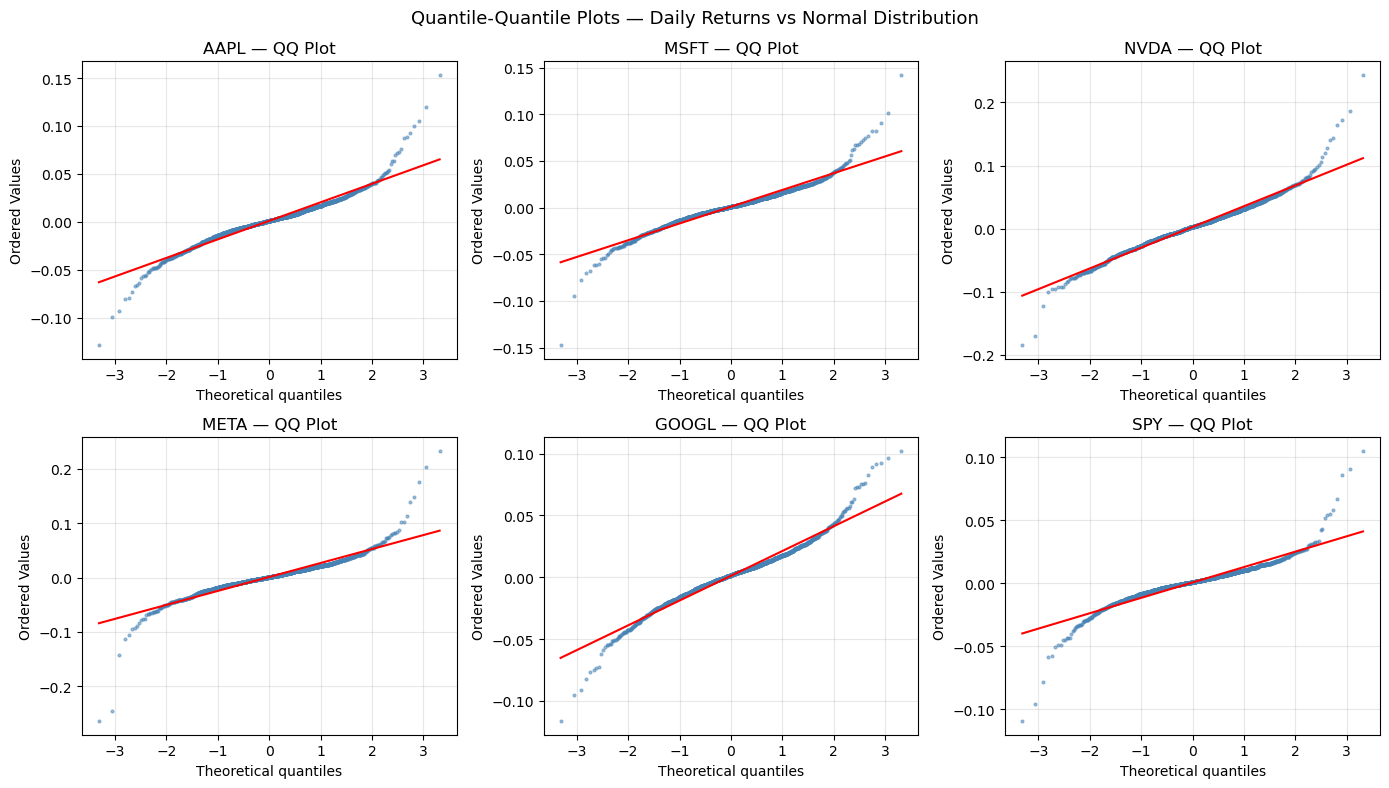

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    stats.probplot(returns[ticker].dropna(), dist="norm", plot=ax)
    ax.set_title(f'{ticker} — QQ Plot')
    ax.get_lines()[0].set(color='steelblue', markersize=2, alpha=0.5)
    ax.get_lines()[1].set(color='red', linewidth=1.5)
    ax.grid(alpha=0.3)

plt.suptitle('Quantile-Quantile Plots — Daily Returns vs Normal Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('charts/qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpreting Quantile-Quantile Plot:
Quantile-Quantile Plot compares the distribution of returns against a theoretical normal distribution.  
If returns were perfectly normal, all points would lie on the red line, not S-shaped.

### Shapiro-Wilk Normality Test
**Hypothesis**
- Null Hypothesis: the returns are normally distributed
- Alternative Hypothesis: the returns are not normally distributed

In [4]:
print("Shapiro-Wilk Normality Test")
print(f"{'Ticker':<8} {'W-stat':>10} {'p-value':>12} {'Normal?':>10}")
print("-" * 45)

for ticker in TICKERS:
    sample = returns[ticker].dropna().sample(1000, random_state=42)
    stat, p = stats.shapiro(sample)
    normal = "YES" if p > 0.05 else "NO"
    print(f"{ticker:<8} {stat:>10.4f} {p:>12.6f} {normal:>10}")

Shapiro-Wilk Normality Test
Ticker       W-stat      p-value    Normal?
---------------------------------------------
AAPL         0.9243     0.000000         NO
MSFT         0.9217     0.000000         NO
NVDA         0.9656     0.000000         NO
META         0.8429     0.000000         NO
GOOGL        0.9608     0.000000         NO
SPY          0.8633     0.000000         NO


**Conclusion**  
p-value < 0.05 -> reject Null Hypothesis -> returns are not normally distributed

### **Part 2 - Tail Risk Analysis**
- Historical Value-at-Risk (VaR)
- Conditional Value-at-Risk (CVaR)
- Maximum Drawdown

In [20]:
# Historical Value-at-Risk (VaR)
def historical_var(returns, confidence_level):
    percentile = 1 - confidence_level
    var = returns.quantile(percentile)
    return var

In [21]:
# Historical Conditional Value-at-Risk (CVaR)
def historical_cvar(returns, confidence_level):
    var = historical_var(returns, confidence_level)
    tail_losses = returns[returns <= var]
    cvar = tail_losses.mean()
    return cvar

In [24]:
tail_risk = pd.DataFrame(index=returns.columns)

tail_risk["VaR (95%)"] = returns.apply(historical_var, confidence_level=0.95)
tail_risk["CVaR (95%)"] = returns.apply(historical_cvar, confidence_level=0.95)
tail_risk["VaR (99%)"] = returns.apply(historical_var, confidence_level=0.99)
tail_risk["CVaR (99%)"] = returns.apply(historical_cvar, confidence_level=0.99)

tail_risk

,VaR (95%),CVaR (95%),VaR (99%),CVaR (99%)
Ticker,,,,
AAPL,-0.030716,-0.044643,-0.049783,-0.070572
GOOGL,-0.030945,-0.046013,-0.051491,-0.070549
META,-0.039971,-0.060192,-0.064412,-0.107953
MSFT,-0.027297,-0.041267,-0.045265,-0.065240
NVDA,-0.049131,-0.070038,-0.077861,-0.100769
SPY,-0.018116,-0.031281,-0.036885,-0.055225


**Maximum Drawdown**  
captures the worst cumulative loss an investor would have experienced before recovering to a new peak.  
**MDD = (through value - peak value) / peak value**

In [29]:
maximum_drawdown = pd.DataFrame(index=returns.columns)

for ticker in returns.columns:
    wealth = (1 + returns[ticker]).cumprod()
    running_peak = wealth.cummax()
    drawdown = wealth / running_peak - 1
    maximum_drawdown.loc[ticker, "Maximum Drawdown"] = drawdown.min()
maximum_drawdown

,Maximum Drawdown
Ticker,
AAPL,-0.333605
GOOGL,-0.443200
META,-0.767361
MSFT,-0.371485
NVDA,-0.663351
SPY,-0.337172


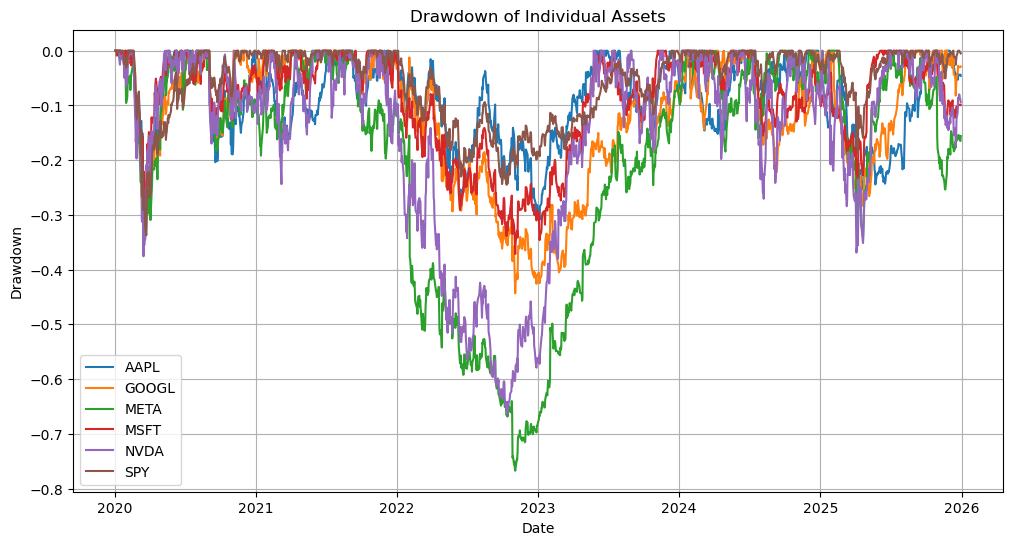

In [31]:
plt.figure(figsize=(12, 6))

for ticker in returns.columns:
    wealth = (1 + returns[ticker]).cumprod()
    running_peak = wealth.cummax()
    drawdown = wealth / running_peak - 1
    plt.plot(drawdown, label=ticker)

plt.title("Drawdown of Individual Assets")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.show()